### Here CNN with categorical cross entropy without augmentation with hyperparameter optimization with grid search and random search

### Dataset

In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

# Extract the dataset
with zipfile.ZipFile("/content/banglaSER_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/banglaSER_extracted")

# Define dataset path
AUDIO_DIR = "/content/banglaSER_extracted"

# Define emotion mapping
EMOTION_MAPPING = {
    '01': 'happy',
    '02': 'sad',
    '03': 'angry',
    '04': 'surprise',
    '05': 'neutral'
}

# Create dataset info function
def create_dataset_info(root_path, extract_duration=True):

    data = []

    for root, _, files in os.walk(root_path):
        for file in files:
            if file.lower().endswith('.wav'):
                parts = file.split('-')
                if len(parts) >= 3:
                    emotion_code = parts[2]
                    emotion = EMOTION_MAPPING.get(emotion_code, 'unknown')
                    file_path = os.path.join(root, file)

                    entry = {
                        'file_path': file_path,
                        'emotion_code': emotion_code,
                        'emotion': emotion
                    }

                    if extract_duration:
                        try:
                            y, sr = librosa.load(file_path, sr=None)
                            duration = librosa.get_duration(y=y, sr=sr)
                            entry['duration_sec'] = duration
                            entry['sample_rate'] = sr
                        except Exception as e:
                            print(f"Could not read {file_path}: {e}")
                            continue

                    data.append(entry)

    return pd.DataFrame(data)

# Create dataset info
df = create_dataset_info(AUDIO_DIR)
print(f"\nTotal samples: {len(df)}")
print("\nEmotion distribution:")
print(df['emotion'].value_counts())
df.head()



Total samples: 1467

Emotion distribution:
emotion
sad         306
happy       306
surprise    306
angry       306
neutral     243
Name: count, dtype: int64


,file_path,emotion_code,emotion,duration_sec,sample_rate
0,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,05,neutral,3.073696,44100
1,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,02,sad,3.863991,44100
2,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,04,surprise,3.634989,44100
3,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,01,happy,3.640000,44100
4,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,01,happy,3.794875,44100


with hyperparameter optimization

Train: 1173, Validation: 147, Test: 147


/tmp/ipython-input-1824813794.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-1824813794.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-1824813794.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


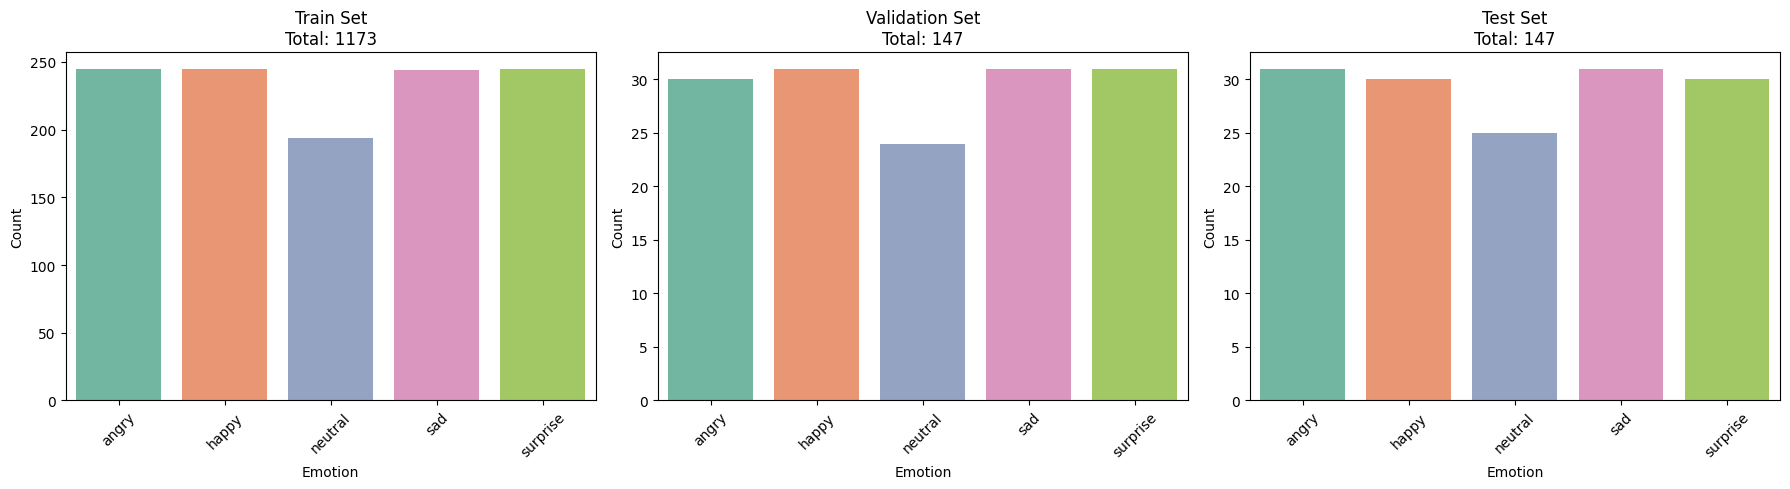

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)


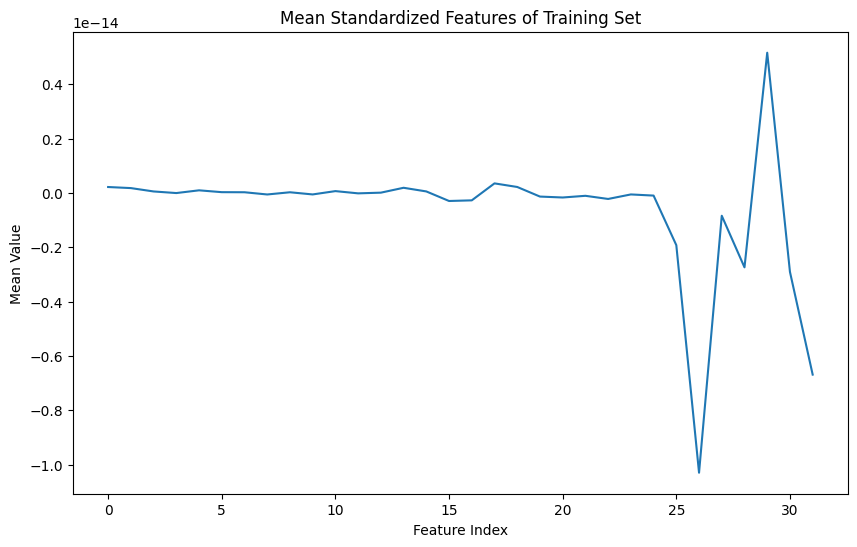

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape: (1173, 32, 1)
X_val reshaped shape: (147, 32, 1)
X_test reshaped shape: (147, 32, 1)
Class weights: {0: np.float64(0.9575510204081633), 1: np.float64(0.9575510204081633), 2: np.float64(1.2092783505154638), 3: np.float64(0.9614754098360656), 4: np.float64(0.9575510204081633)}
Starting Random Search Hyperparameter Optimization...
Running 30 random search iterations...

Random Search Iteration 1/30
Testing parameters: {'activation': 'swish', 'batch_size': 16, 'conv1_filters': 46, 'conv1_kernel_size': 7, 'conv2_filters': 135, 'conv2_kernel_size': 3, 'conv3_filters': 148, 'conv3_kernel_size': 3, 'conv_dropout': np.float64(0.2783331011414365), 'dense1_units': 278, 'dense2_units': 106, 'dense_dropout': np.float64(0.4755493351795203), 'early_stopping_patience': 14, 'learning_rate': np.float64(0.0055100351056888795), 'pool1_size': 3, 'pool2_size': 2, 'pool3_size': 3, 'reduce_lr_patience': 7, 'use_global_pooli

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Val Accuracy: 0.8095, Val Loss: 0.6330
Training time: 67.3 seconds

Random Search Iteration 2/30
Testing parameters: {'activation': 'elu', 'batch_size': 32, 'conv1_filters': 33, 'conv1_kernel_size': 3, 'conv2_filters': 224, 'conv2_kernel_size': 5, 'conv3_filters': 149, 'conv3_kernel_size': 3, 'conv_dropout': np.float64(0.2727780074568463), 'dense1_units': 112, 'dense2_units': 250, 'dense_dropout': np.float64(0.5671117368334277), 'early_stopping_patience': 19, 'learning_rate': np.float64(0.0005199909689225388), 'pool1_size': 3, 'pool2_size': 3, 'pool3_size': 2, 'reduce_lr_patience': 5, 'use_global_pooling': False, 'use_second_dense': True, 'use_third_conv': False}
Val Accuracy: 0.7007, Val Loss: 0.7529
Training time: 76.3 seconds

Random Search Iteration 3/30
Testing parameters: {'activation': 'relu', 'batch_size': 64, 'conv1_filters': 82, 'conv1_kernel_size': 7, 'conv2_filters': 84, 'conv2_kernel_size': 3, 'conv3_filters': 294, 'conv3_kernel_size': 5, 'conv_dropout': np.float64(0.47955

In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for CNN model input (adding channel dimension)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Handle class imbalance with class weights
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary for use in model.fit
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

# ==================== HYPERPARAMETER OPTIMIZATION ====================

import itertools
import json
from datetime import datetime
import pandas as pd
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform, randint

# Enhanced CNN model builder with hyperparameters
def build_cnn_model_with_hyperparams(input_shape, num_classes, hyperparams):
    model = models.Sequential()

    # First Convolutional Layer
    model.add(layers.Conv1D(
        hyperparams['conv1_filters'],
        kernel_size=hyperparams['conv1_kernel_size'],
        activation=hyperparams['activation'],
        padding='same',
        input_shape=input_shape
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=hyperparams['pool1_size']))
    model.add(layers.Dropout(hyperparams['conv_dropout']))

    # Second Convolutional Layer
    model.add(layers.Conv1D(
        hyperparams['conv2_filters'],
        kernel_size=hyperparams['conv2_kernel_size'],
        activation=hyperparams['activation'],
        padding='same'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=hyperparams['pool2_size']))
    model.add(layers.Dropout(hyperparams['conv_dropout']))

    # Third Convolutional Layer (optional based on hyperparameter)
    if hyperparams['use_third_conv']:
        model.add(layers.Conv1D(
            hyperparams['conv3_filters'],
            kernel_size=hyperparams['conv3_kernel_size'],
            activation=hyperparams['activation'],
            padding='same'
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling1D(pool_size=hyperparams['pool3_size']))
        model.add(layers.Dropout(hyperparams['conv_dropout']))

    # Global pooling or flatten
    if hyperparams['use_global_pooling']:
        model.add(layers.GlobalAveragePooling1D())
    else:
        model.add(layers.Flatten())

    # Dense layers
    model.add(layers.Dense(hyperparams['dense1_units'], activation=hyperparams['activation']))
    model.add(layers.Dropout(hyperparams['dense_dropout']))

    if hyperparams['use_second_dense']:
        model.add(layers.Dense(hyperparams['dense2_units'], activation=hyperparams['activation']))
        model.add(layers.Dropout(hyperparams['dense_dropout']))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Function to train and evaluate model with given hyperparameters
def train_evaluate_model(hyperparams, X_train, y_train, X_val, y_val, input_shape, num_classes,
                        class_weight_dict, max_epochs=100, verbose=0):
    """
    Train and evaluate a model with given hyperparameters
    """
    try:
        # Build model
        model = build_cnn_model_with_hyperparams(input_shape, num_classes, hyperparams)

        # Compile model
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=hyperparams['learning_rate']),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Define callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=hyperparams['early_stopping_patience'],
                restore_best_weights=True,
                verbose=0
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.2,
                patience=hyperparams['reduce_lr_patience'],
                min_lr=0.00001,
                verbose=0
            )
        ]

        # Train model
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=max_epochs,
            batch_size=hyperparams['batch_size'],
            callbacks=callbacks,
            class_weight=class_weight_dict,
            verbose=verbose
        )

        # Get best validation accuracy and loss
        best_val_accuracy = max(history.history['val_accuracy'])
        best_val_loss = min(history.history['val_loss'])

        # Clean up model to free memory
        del model
        tf.keras.backend.clear_session()

        return {
            'val_accuracy': best_val_accuracy,
            'val_loss': best_val_loss,
            'epochs_trained': len(history.history['val_accuracy'])
        }

    except Exception as e:
        print(f"Error training model: {e}")
        return {
            'val_accuracy': 0.0,
            'val_loss': float('inf'),
            'epochs_trained': 0
        }

# ==================== RANDOM SEARCH ====================

print("Starting Random Search Hyperparameter Optimization...")

# Define hyperparameter search space for random search
random_search_space = {
    'conv1_filters': randint(32, 129),  # 32 to 128
    'conv1_kernel_size': [3, 5, 7],
    'conv2_filters': randint(64, 257),  # 64 to 256
    'conv2_kernel_size': [3, 5, 7],
    'conv3_filters': randint(128, 513),  # 128 to 512
    'conv3_kernel_size': [3, 5],
    'pool1_size': [2, 3],
    'pool2_size': [2, 3],
    'pool3_size': [2, 3],
    'use_third_conv': [True, False],
    'use_global_pooling': [True, False],
    'dense1_units': randint(64, 513),  # 64 to 512
    'dense2_units': randint(32, 257),  # 32 to 256
    'use_second_dense': [True, False],
    'conv_dropout': uniform(0.1, 0.4),  # 0.1 to 0.5
    'dense_dropout': uniform(0.2, 0.6),  # 0.2 to 0.8
    'learning_rate': uniform(0.0001, 0.009),  # 0.0001 to 0.01
    'batch_size': [16, 32, 64],
    'activation': ['relu', 'elu', 'swish'],
    'early_stopping_patience': randint(10, 21),  # 10 to 20
    'reduce_lr_patience': randint(3, 8)  # 3 to 7
}

# Number of random search iterations
n_random_iter = 30  # Adjust based on computational resources

# Generate random hyperparameter combinations
random_params = list(ParameterSampler(random_search_space, n_iter=n_random_iter, random_state=42))

# Store results
random_search_results = []
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]

print(f"Running {n_random_iter} random search iterations...")

for i, params in enumerate(random_params):
    print(f"\nRandom Search Iteration {i+1}/{n_random_iter}")
    print(f"Testing parameters: {params}")

    start_time = datetime.now()

    # Train and evaluate model
    results = train_evaluate_model(
        params, X_train, y_train, X_val, y_val,
        input_shape, num_classes, class_weight_dict,
        max_epochs=100, verbose=0
    )

    end_time = datetime.now()
    training_time = (end_time - start_time).total_seconds()

    # Store results
    result_entry = {
        'iteration': i+1,
        'hyperparams': params.copy(),
        'val_accuracy': results['val_accuracy'],
        'val_loss': results['val_loss'],
        'epochs_trained': results['epochs_trained'],
        'training_time_seconds': training_time
    }

    random_search_results.append(result_entry)

    print(f"Val Accuracy: {results['val_accuracy']:.4f}, Val Loss: {results['val_loss']:.4f}")
    print(f"Training time: {training_time:.1f} seconds")

# Sort results by validation accuracy
random_search_results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Display top 5 results from random search
print("\n" + "="*50)
print("TOP 5 RANDOM SEARCH RESULTS:")
print("="*50)

for i, result in enumerate(random_search_results[:5]):
    print(f"\nRank {i+1}:")
    print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"Validation Loss: {result['val_loss']:.4f}")
    print(f"Epochs Trained: {result['epochs_trained']}")
    print(f"Training Time: {result['training_time_seconds']:.1f}s")
    print("Hyperparameters:")
    for key, value in result['hyperparams'].items():
        print(f"  {key}: {value}")

# ==================== GRID SEARCH BASED ON RANDOM SEARCH RESULTS ====================

print("\n" + "="*50)
print("STARTING GRID SEARCH BASED ON RANDOM SEARCH RESULTS")
print("="*50)

# Analyze top performing hyperparameters from random search
top_n = 5
top_results = random_search_results[:top_n]

# Extract common patterns from top performers
def analyze_top_hyperparams(top_results):
    analysis = {}

    for key in top_results[0]['hyperparams'].keys():
        values = [result['hyperparams'][key] for result in top_results]

        if isinstance(values[0], bool):
            # For boolean values, find the most common
            analysis[key] = max(set(values), key=values.count)
        elif isinstance(values[0], str):
            # For string values, find the most common
            analysis[key] = max(set(values), key=values.count)
        elif isinstance(values[0], int):
            # For integer values, create a range around the median
            median_val = int(np.median(values))
            min_val = max(int(np.min(values)), median_val - 32)
            max_val = min(int(np.max(values)), median_val + 32)
            analysis[key] = [min_val, median_val, max_val]
        else:  # float values
            # For float values, create a range around the median
            median_val = np.median(values)
            min_val = max(np.min(values), median_val * 0.5)
            max_val = min(np.max(values), median_val * 1.5)
            analysis[key] = [min_val, median_val, max_val]

    return analysis

# Analyze top results
hyperparams_analysis = analyze_top_hyperparams(top_results)

print("Analysis of top performing hyperparameters:")
for key, value in hyperparams_analysis.items():
    print(f"{key}: {value}")

# Define focused grid search space based on random search results
grid_search_space = {
    'conv1_filters': hyperparams_analysis['conv1_filters'] if isinstance(hyperparams_analysis['conv1_filters'], list) else [hyperparams_analysis['conv1_filters']],
    'conv1_kernel_size': [hyperparams_analysis['conv1_kernel_size']] if not isinstance(hyperparams_analysis['conv1_kernel_size'], list) else hyperparams_analysis['conv1_kernel_size'],
    'conv2_filters': hyperparams_analysis['conv2_filters'] if isinstance(hyperparams_analysis['conv2_filters'], list) else [hyperparams_analysis['conv2_filters']],
    'conv2_kernel_size': [hyperparams_analysis['conv2_kernel_size']] if not isinstance(hyperparams_analysis['conv2_kernel_size'], list) else hyperparams_analysis['conv2_kernel_size'],
    'conv3_filters': hyperparams_analysis['conv3_filters'] if isinstance(hyperparams_analysis['conv3_filters'], list) else [hyperparams_analysis['conv3_filters']],
    'conv3_kernel_size': [hyperparams_analysis['conv3_kernel_size']] if not isinstance(hyperparams_analysis['conv3_kernel_size'], list) else hyperparams_analysis['conv3_kernel_size'],
    'pool1_size': [hyperparams_analysis['pool1_size']] if not isinstance(hyperparams_analysis['pool1_size'], list) else hyperparams_analysis['pool1_size'],
    'pool2_size': [hyperparams_analysis['pool2_size']] if not isinstance(hyperparams_analysis['pool2_size'], list) else hyperparams_analysis['pool2_size'],
    'pool3_size': [hyperparams_analysis['pool3_size']] if not isinstance(hyperparams_analysis['pool3_size'], list) else hyperparams_analysis['pool3_size'],
    'use_third_conv': [hyperparams_analysis['use_third_conv']],
    'use_global_pooling': [hyperparams_analysis['use_global_pooling']],
    'dense1_units': hyperparams_analysis['dense1_units'] if isinstance(hyperparams_analysis['dense1_units'], list) else [hyperparams_analysis['dense1_units']],
    'dense2_units': hyperparams_analysis['dense2_units'] if isinstance(hyperparams_analysis['dense2_units'], list) else [hyperparams_analysis['dense2_units']],
    'use_second_dense': [hyperparams_analysis['use_second_dense']],
    'conv_dropout': hyperparams_analysis['conv_dropout'] if isinstance(hyperparams_analysis['conv_dropout'], list) else [hyperparams_analysis['conv_dropout']],
    'dense_dropout': hyperparams_analysis['dense_dropout'] if isinstance(hyperparams_analysis['dense_dropout'], list) else [hyperparams_analysis['dense_dropout']],
    'learning_rate': hyperparams_analysis['learning_rate'] if isinstance(hyperparams_analysis['learning_rate'], list) else [hyperparams_analysis['learning_rate']],
    'batch_size': [hyperparams_analysis['batch_size']] if not isinstance(hyperparams_analysis['batch_size'], list) else hyperparams_analysis['batch_size'],
    'activation': [hyperparams_analysis['activation']],
    'early_stopping_patience': [hyperparams_analysis['early_stopping_patience']] if not isinstance(hyperparams_analysis['early_stopping_patience'], list) else hyperparams_analysis['early_stopping_patience'],
    'reduce_lr_patience': [hyperparams_analysis['reduce_lr_patience']] if not isinstance(hyperparams_analysis['reduce_lr_patience'], list) else hyperparams_analysis['reduce_lr_patience']
}

# Generate all combinations for grid search
grid_combinations = list(itertools.product(*grid_search_space.values()))
grid_keys = list(grid_search_space.keys())

print(f"\nGrid search will test {len(grid_combinations)} combinations")

# Limit grid search iterations to manageable number
max_grid_iterations = min(20, len(grid_combinations))
if len(grid_combinations) > max_grid_iterations:
    # Sample random combinations if there are too many
    import random
    random.seed(42)
    grid_combinations = random.sample(grid_combinations, max_grid_iterations)

grid_search_results = []

print(f"Running {len(grid_combinations)} grid search iterations...")

for i, combination in enumerate(grid_combinations):
    # Create hyperparameter dictionary
    params = dict(zip(grid_keys, combination))

    print(f"\nGrid Search Iteration {i+1}/{len(grid_combinations)}")
    print(f"Testing parameters: {params}")

    start_time = datetime.now()

    # Train and evaluate model
    results = train_evaluate_model(
        params, X_train, y_train, X_val, y_val,
        input_shape, num_classes, class_weight_dict,
        max_epochs=100, verbose=0
    )

    end_time = datetime.now()
    training_time = (end_time - start_time).total_seconds()

    # Store results
    result_entry = {
        'iteration': i+1,
        'hyperparams': params.copy(),
        'val_accuracy': results['val_accuracy'],
        'val_loss': results['val_loss'],
        'epochs_trained': results['epochs_trained'],
        'training_time_seconds': training_time
    }

    grid_search_results.append(result_entry)

    print(f"Val Accuracy: {results['val_accuracy']:.4f}, Val Loss: {results['val_loss']:.4f}")
    print(f"Training time: {training_time:.1f} seconds")

# Sort grid search results by validation accuracy
grid_search_results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Display top 5 results from grid search
print("\n" + "="*50)
print("TOP 5 GRID SEARCH RESULTS:")
print("="*50)

for i, result in enumerate(grid_search_results[:5]):
    print(f"\nRank {i+1}:")
    print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"Validation Loss: {result['val_loss']:.4f}")
    print(f"Epochs Trained: {result['epochs_trained']}")
    print(f"Training Time: {result['training_time_seconds']:.1f}s")
    print("Hyperparameters:")
    for key, value in result['hyperparams'].items():
        print(f"  {key}: {value}")

# ==================== FINAL MODEL TRAINING ====================

print("\n" + "="*50)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*50)

# Get the best hyperparameters
best_hyperparams = grid_search_results[0]['hyperparams']

print("Best hyperparameters:")
for key, value in best_hyperparams.items():
    print(f"  {key}: {value}")

# Build and train final model
final_model = build_cnn_model_with_hyperparams(input_shape, num_classes, best_hyperparams)

# Compile final model
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyperparams['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
print("\nFinal model architecture:")
final_model.summary()

# Define callbacks for final training
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=best_hyperparams['early_stopping_patience'],
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_optimized_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=best_hyperparams['reduce_lr_patience'],
        min_lr=0.00001,
        verbose=1
    )
]

# Train final model
print("\nTraining final optimized model...")
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=best_hyperparams['batch_size'],
    callbacks=final_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training history
plt.figure(figsize=(15, 5))

# Plot accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Final Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Final Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot learning rate
if 'lr' in history.history:
    plt.subplot(1, 3, 3)
    plt.plot(history.history['lr'])
    plt.title('Learning Rate')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nFinal Model Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Optimized Model - Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save results to files
print("\nSaving optimization results...")

# Save random search results
random_search_df = pd.DataFrame([
    {**result['hyperparams'],
     'val_accuracy': result['val_accuracy'],
     'val_loss': result['val_loss'],
     'epochs_trained': result['epochs_trained'],
     'training_time_seconds': result['training_time_seconds']}
    for result in random_search_results
])
random_search_df.to_csv('random_search_results.csv', index=False)

# Save grid search results
grid_search_df = pd.DataFrame([
    {**result['hyperparams'],
     'val_accuracy': result['val_accuracy'],
     'val_loss': result['val_loss'],
     'epochs_trained': result['epochs_trained'],
     'training_time_seconds': result['training_time_seconds']}
    for result in grid_search_results
])
grid_search_df.to_csv('grid_search_results.csv', index=False)

# Save best hyperparameters
with open('best_hyperparameters.json', 'w') as f:
    json.dump(best_hyperparams, f, indent=2)

# Save the final optimized model
final_model.save('bangla_ser_optimized_cnn_model.h5')
print("Optimized model saved as 'bangla_ser_optimized_cnn_model.h5'")

# Comparison with original model results
print("\n" + "="*50)
print("OPTIMIZATION SUMMARY")
print("="*50)
print(f"Random Search - Best Validation Accuracy: {random_search_results[0]['val_accuracy']:.4f}")
print(f"Grid Search - Best Validation Accuracy: {grid_search_results[0]['val_accuracy']:.4f}")
print(f"Final Optimized Model - Test Accuracy: {test_accuracy:.4f}")

# Example function for predicting emotion with optimized model
def predict_emotion_optimized(audio_path, model, scaler, label_encoder):
    # Extract features from audio
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for model input
    features = features.reshape(1, -1, 1)

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class index and probability
    predicted_index = np.argmax(prediction)
    probability = prediction[predicted_index]

    # Convert index to emotion label
    emotion = label_encoder.classes_[predicted_index]

    return emotion, probability, prediction

print("\nHyperparameter optimization complete!")
print("Files saved:")
print("- random_search_results.csv")
print("- grid_search_results.csv")
print("- best_hyperparameters.json")
print("- bangla_ser_optimized_cnn_model.h5")

### Final one with hyperparameter optimization

In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for CNN model input (adding channel dimension)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Handle class imbalance with class weights
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary for use in model.fit
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

In [ ]:

import gc
import json
from datetime import datetime
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform, randint

# Clear any existing models from memory
tf.keras.backend.clear_session()
gc.collect()

# Simplified CNN model builder (more memory efficient)
def build_simple_cnn_model(input_shape, num_classes, hyperparams):
    model = models.Sequential()

    # First Conv Layer
    model.add(layers.Conv1D(
        hyperparams['conv1_filters'],
        kernel_size=hyperparams['conv1_kernel_size'],
        activation=hyperparams['activation'],
        padding='same',
        input_shape=input_shape
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Dropout(hyperparams['conv_dropout']))

    # Second Conv Layer
    model.add(layers.Conv1D(
        hyperparams['conv2_filters'],
        kernel_size=hyperparams['conv2_kernel_size'],
        activation=hyperparams['activation'],
        padding='same'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Dropout(hyperparams['conv_dropout']))

    # Global pooling (more memory efficient than flatten)
    model.add(layers.GlobalAveragePooling1D())

    # Dense layer
    model.add(layers.Dense(hyperparams['dense_units'], activation=hyperparams['activation']))
    model.add(layers.Dropout(hyperparams['dense_dropout']))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Memory-efficient training function
def train_evaluate_model_efficient(hyperparams, X_train, y_train, X_val, y_val,
                                 input_shape, num_classes, class_weight_dict):
    try:
        # Clear memory before creating new model
        tf.keras.backend.clear_session()
        gc.collect()

        # Build model
        model = build_simple_cnn_model(input_shape, num_classes, hyperparams)

        # Compile model
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=hyperparams['learning_rate']),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Callbacks with shorter patience for faster training
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=5,  # Reduced patience
                restore_best_weights=True,
                verbose=0
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=3,
                min_lr=0.00001,
                verbose=0
            )
        ]

        # Train with fewer epochs
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,  # Reduced epochs
            batch_size=hyperparams['batch_size'],
            callbacks=callbacks,
            class_weight=class_weight_dict,
            verbose=0
        )

        # Get results
        best_val_accuracy = max(history.history['val_accuracy'])
        best_val_loss = min(history.history['val_loss'])
        epochs_trained = len(history.history['val_accuracy'])

        # Clean up immediately
        del model, history
        tf.keras.backend.clear_session()
        gc.collect()

        return {
            'val_accuracy': best_val_accuracy,
            'val_loss': best_val_loss,
            'epochs_trained': epochs_trained
        }

    except Exception as e:
        print(f"Error in training: {e}")
        # Clean up on error
        tf.keras.backend.clear_session()
        gc.collect()
        return {
            'val_accuracy': 0.0,
            'val_loss': float('inf'),
            'epochs_trained': 0
        }

# Simplified hyperparameter search space
simple_search_space = {
    'conv1_filters': [32, 64, 128],
    'conv1_kernel_size': [3, 5],
    'conv2_filters': [64, 128, 256],
    'conv2_kernel_size': [3, 5],
    'dense_units': [64, 128, 256],
    'conv_dropout': uniform(0.2, 0.3),  # 0.2 to 0.5
    'dense_dropout': uniform(0.3, 0.4),  # 0.3 to 0.7
    'learning_rate': uniform(0.0001, 0.004),  # 0.0001 to 0.005
    'batch_size': [32, 64],
    'activation': ['relu', 'elu']
}

# Reduced number of iterations for Colab
n_iterations = 10  # Much smaller for Colab constraints

print(f"Starting Memory-Efficient Random Search with {n_iterations} iterations...")

# Generate random parameter combinations
random_params = list(ParameterSampler(simple_search_space, n_iter=n_iterations, random_state=42))

# Store results
results = []
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]

# Run random search
for i, params in enumerate(random_params):
    print(f"\nIteration {i+1}/{n_iterations}")
    print(f"Parameters: {params}")

    start_time = datetime.now()

    # Train and evaluate
    result = train_evaluate_model_efficient(
        params, X_train, y_train, X_val, y_val,
        input_shape, num_classes, class_weight_dict
    )

    end_time = datetime.now()
    training_time = (end_time - start_time).total_seconds()

    # Store result
    result_entry = {
        'iteration': i+1,
        'hyperparams': params.copy(),
        'val_accuracy': result['val_accuracy'],
        'val_loss': result['val_loss'],
        'epochs_trained': result['epochs_trained'],
        'training_time_seconds': training_time
    }

    results.append(result_entry)

    print(f"Val Accuracy: {result['val_accuracy']:.4f}")
    print(f"Val Loss: {result['val_loss']:.4f}")
    print(f"Time: {training_time:.1f}s")

    # Force garbage collection after each iteration
    gc.collect()

# Sort results by validation accuracy
results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Display top results
print("\n" + "="*60)
print("TOP RANDOM SEARCH RESULTS:")
print("="*60)

for i, result in enumerate(results[:5]):
    print(f"\nRank {i+1}:")
    print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"Validation Loss: {result['val_loss']:.4f}")
    print(f"Epochs: {result['epochs_trained']}")
    print(f"Time: {result['training_time_seconds']:.1f}s")
    print("Parameters:")
    for key, value in result['hyperparams'].items():
        if isinstance(value, float):
            print(f"  {key}: {value:.4f}")
        else:
            print(f"  {key}: {value}")

# Train final model with best hyperparameters
print("\n" + "="*60)
print("TRAINING FINAL MODEL WITH BEST PARAMETERS")
print("="*60)

best_params = results[0]['hyperparams']
print("\nBest parameters:")
for key, value in best_params.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Clear memory before final training
tf.keras.backend.clear_session()
gc.collect()

# Build final model
final_model = build_simple_cnn_model(input_shape, num_classes, best_params)

# Compile final model
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nFinal model architecture:")
final_model.summary()

# Train final model with more epochs
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

print("\nTraining final model...")
final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,  # More epochs for final training
    batch_size=best_params['batch_size'],
    callbacks=final_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)

print(f"\nFINAL RESULTS:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(final_history.history['accuracy'], label='Train')
plt.plot(final_history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history['loss'], label='Train')
plt.plot(final_history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Generate predictions and classification report
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save the optimized model and results
final_model.save('bangla_ser_optimized_model.h5')

# Save best parameters
with open('best_hyperparameters.json', 'w') as f:
    # Convert numpy types to native Python types for JSON serialization
    best_params_json = {}
    for key, value in best_params.items():
        if isinstance(value, (np.integer, np.floating)):
            best_params_json[key] = value.item()
        else:
            best_params_json[key] = value
    json.dump(best_params_json, f, indent=2)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"Best validation accuracy from random search: {results[0]['val_accuracy']:.4f}")
print(f"Final test accuracy: {test_accuracy:.4f}")
print("\nFiles saved:")
print("- bangla_ser_optimized_model.h5")
print("- best_hyperparameters.json")

# Clean up final memory
del final_model
tf.keras.backend.clear_session()
gc.collect()

print("\nMemory cleaned up successfully!")